In [1]:
# Import libs
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

In [50]:
### Read in CSV files (Core data files):

# us_csv = pd.read_csv("./Kaggle_data/USvideos.csv")
#       --------- OR ---------
url_data = "https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/5ea29c1040625fc0ce6c182923120796e1f6ecd1/Cap3_AirPassengers/2_DataWrangling/Kaggle_data/AirPassengers.csv"
csv_data = pd.read_csv(url_data)

print("CSV dimensions: ", csv_data.shape)


CSV dimensions:  (144, 2)


In [51]:
csv_data.rename(columns={'Month':'date', '#Passengers':'n_passengers'}, inplace=True)
csv_data.set_index('date', inplace=True)

# Set Frequency to avoid error when scoring ARIMA later
csv_data.index = pd.DatetimeIndex(csv_data.index.values, freq='MS')

csv_data.head()

,n_passengers
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


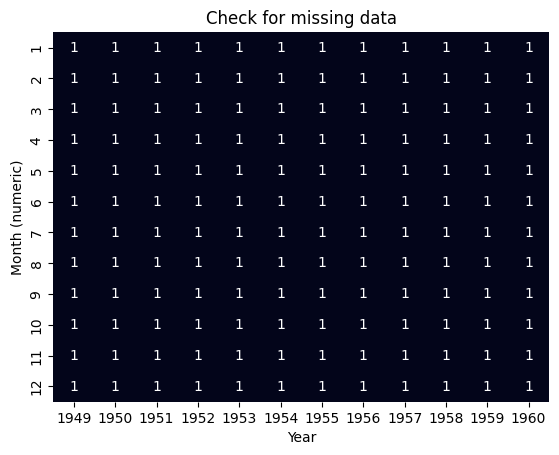

In [41]:
heat_dt1 = csv_data.copy().reset_index(names="date")
heat_dt1["status"] = heat_dt1['n_passengers'].apply(lambda x: 1 if x>0 and x is not None else 0)
heat_dt1["month"]  = heat_dt1['date'].dt.month
heat_dt1["year"]   = heat_dt1['date'].dt.year

heat_dt2 = pd.DataFrame(heat_dt1, columns=['status','month','year']).set_index(['month','year']).\
            pivot_table(index='month', columns='year', values='status')

# heat_dt2.iloc[0,4] = 0
sns.heatmap(heat_dt2, annot=True, cbar=False)
plt. title("Check for missing data")
plt.xlabel("Year")
plt.ylabel("Month (numeric)")
plt.show()

In [42]:
csv_data.head()

,n_passengers
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


<Figure size 1000x700 with 0 Axes>

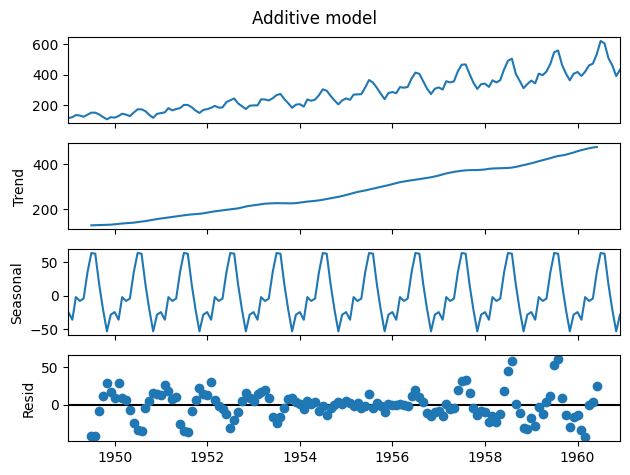

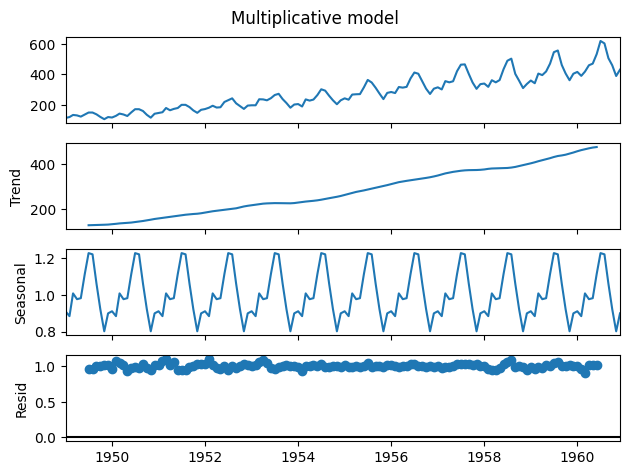

In [52]:
from statsmodels.tsa.seasonal import seasonal_decompose
plt.figure(figsize=(10, 7))
decomp1 = seasonal_decompose(csv_data['n_passengers'], period=12, model='additive')
add_fig = decomp1.plot()
for ax in add_fig.axes:
    ax.set_title("")
add_fig.suptitle("Additive model")
plt.xlabel("")
plt.show()

decomp2 = seasonal_decompose(csv_data['n_passengers'], period=12, model='multiplicative')
mul_fig = decomp2.plot()
for ax in mul_fig.axes:
    ax.set_title("")
mul_fig.suptitle("Multiplicative model")
plt.show()

The additive models still leaves behind some trends in the residuals after decomposition. Thus **multiplicative model** was chosen for decomposition!

In [53]:
# Dickey-Fuller test
diff_data = csv_data["n_passengers"].diff(2).dropna()
result = adfuller(diff_data)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])

ADF Statistic: -2.961695135555418
p-value: 0.03862975767698902
Critical Values: {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}


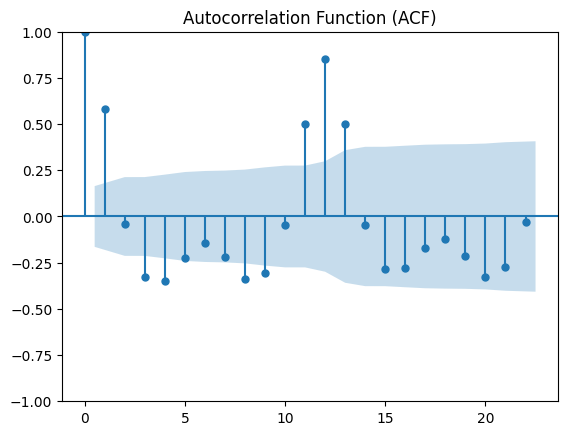

In [54]:
plot_acf(diff_data)
plt.title("Autocorrelation Function (ACF)")
plt.show()

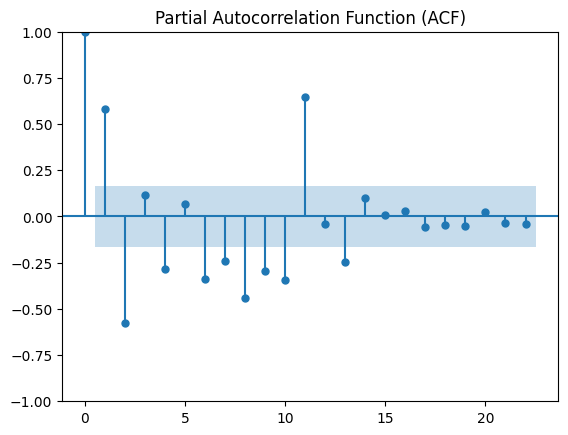

In [55]:
plot_pacf(diff_data)
plt.title("Partial Autocorrelation Function (ACF)")
plt.show()

In [216]:
#Split data for Training & Testing:
split_at_n = int(np.floor(0.7*csv_data.shape[0]))
train, test = csv_data[:split_at_n], csv_data[split_at_n:]

In [217]:
import warnings

warnings.filterwarnings("error", category=UserWarning)  # Convert UserWarning into an exception
def evaluate_arima(dt, arima_order):
  try:
    arima = ARIMA(dt, order = arima_order, freq="MS")
    arima_fit  = arima.fit()
    res = arima_fit.aic
  except:
    res = np.inf
  return res

# evaluate_arima(train, (0, 0, 2))
score_list = []
order_list = []
for p in range(4):
  for d in range(4):
    for q in range(4):
      aic_result = round(evaluate_arima(train, (p, d, q)), 3);
      if aic_result != np.inf:
        score_list.append(aic_result)
        order_list.append((p, d, q))
        print(f"ARIMA({p}, {d}, {q}) = {aic_result}")

warnings.resetwarnings()

ARIMA(0, 0, 0) = 1148.191
ARIMA(0, 0, 2) = 989.32
ARIMA(0, 1, 0) = 908.785
ARIMA(0, 1, 1) = 903.548
ARIMA(0, 1, 2) = 899.468
ARIMA(0, 1, 3) = 899.533
ARIMA(0, 2, 0) = 944.396
ARIMA(0, 2, 1) = 906.212
ARIMA(0, 2, 2) = 900.921
ARIMA(0, 2, 3) = 897.019
ARIMA(0, 3, 0) = 1023.995
ARIMA(0, 3, 1) = 942.352
ARIMA(0, 3, 3) = 903.863
ARIMA(1, 0, 0) = 923.022
ARIMA(1, 0, 1) = 915.851
ARIMA(1, 0, 2) = 913.86
ARIMA(1, 0, 3) = 915.12
ARIMA(1, 1, 0) = 906.025
ARIMA(1, 1, 1) = 898.911
ARIMA(1, 1, 2) = 895.892
ARIMA(1, 1, 3) = 897.591
ARIMA(1, 2, 0) = 938.979
ARIMA(1, 2, 1) = 903.381
ARIMA(1, 2, 2) = 896.358
ARIMA(1, 2, 3) = 898.195
ARIMA(1, 3, 0) = 998.171
ARIMA(1, 3, 1) = 937.488
ARIMA(1, 3, 3) = 901.291
ARIMA(2, 0, 0) = 918.706
ARIMA(2, 0, 1) = 912.376
ARIMA(2, 0, 3) = 913.25
ARIMA(2, 1, 0) = 903.746
ARIMA(2, 1, 1) = 896.369
ARIMA(2, 1, 2) = 896.434
ARIMA(2, 2, 0) = 929.463
ARIMA(2, 2, 1) = 901.289
ARIMA(2, 2, 2) = 898.244
ARIMA(2, 2, 3) = 899.841
ARIMA(2, 3, 0) = 968.543
ARIMA(2, 3, 1) = 928.652
AR

In [218]:
summary_dict = dict(zip(order_list, score_list))

min_value = min(summary_dict.values())
best_arima_order, best_arima_score = [(key,value) for key, value in summary_dict.items() if value == min_value][0]

print(f"Best ARIMA params (p, d, q) = {best_arima_order}. \nScore = {best_arima_order}")

Best ARIMA params (p, d, q) = (3, 1, 2). 
Score = (3, 1, 2)


In [227]:
# Fit ARIMA model (p, d, q) parameters
model = ARIMA(test, order = best_arima_order)
model_fit = model.fit()

# Print summary of the model
print(model_fit.summary())

# Forecast next 10 steps
predicted = model_fit.forecast(steps=len(test)).rename("n_passengers")
# print("Forecast:", predicted)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:           n_passengers   No. Observations:                   44
Model:                 ARIMA(3, 1, 2)   Log Likelihood                -220.597
Date:                Wed, 14 May 2025   AIC                            453.194
Time:                        03:44:08   BIC                            463.761
Sample:                    05-01-1957   HQIC                           457.091
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3015      0.448      0.673      0.501      -0.577       1.180
ar.L2          0.3799      0.486      0.781      0.435      -0.573       1.333
ar.L3         -0.4253      0.358     -1.187      0.2

(144, 1)
(144, 2)


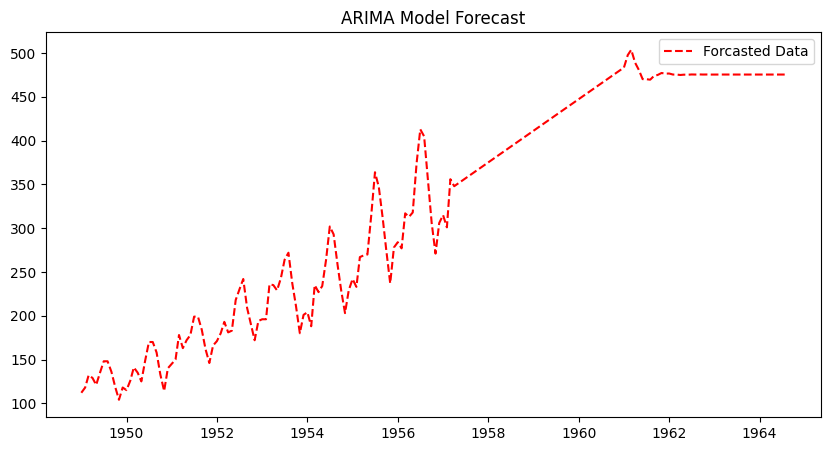

In [228]:
forecast_dt = pd.concat([train, predicted])
original_data = csv_data.copy().reset_index()

print(forecast_dt.shape)
print(original_data.shape)

# Plot actual vs forecasted values
plt.figure(figsize=(10, 5))
# plt.plot(original_data.index, original_data["n_passengers"], label="Actual Data")
plt.plot(forecast_dt.index, forecast_dt["n_passengers"], label="Forcasted Data", linestyle="dashed", color="red")
plt.legend()
plt.title("ARIMA Model Forecast")
plt.show()